# Keşif

In [1]:
import numpy as np
import pandas as pd
%load_ext autoreload
%autoreload 2
import os

## Veriyi Al

In [2]:
from olist.data import Olist
data = Olist().get_data()

Olist e-ticaret platformundaki her işlem şu özelliklere sahiptir:
- satın alacak olan bir `customer_id`...
- çeşitli `product_id`...
- bir `seller_id`...
- ve bir `review_id`...
- tüm bunlar bir `order_id`'ye aittir.

## Çeşitli DataFrame'lerinizin kardinalitelerini araştırın

❓ **Kaç tane benzersiz `orders`, `reviews`, `sellers`, `products` and `customers` var ?**

In [ ]:
data.keys()

dict_keys(['sellers', 'product_category_name_translation', 'orders', 'order_items', 'customers', 'geolocation', 'order_payments', 'order_reviews', 'products'])

In [6]:
for key, value in data.items():
    print(key, value.columns)

sellers Index(['seller_id', 'seller_zip_code_prefix', 'seller_city', 'seller_state'], dtype='object')
product_category_name_translation Index(['product_category_name', 'product_category_name_english'], dtype='object')
orders Index(['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp',
       'order_approved_at', 'order_delivered_carrier_date',
       'order_delivered_customer_date', 'order_estimated_delivery_date'],
      dtype='object')
order_items Index(['order_id', 'order_item_id', 'product_id', 'seller_id',
       'shipping_limit_date', 'price', 'freight_value'],
      dtype='object')
customers Index(['customer_id', 'customer_unique_id', 'customer_zip_code_prefix',
       'customer_city', 'customer_state'],
      dtype='object')
geolocation Index(['geolocation_zip_code_prefix', 'geolocation_lat', 'geolocation_lng',
       'geolocation_city', 'geolocation_state'],
      dtype='object')
order_payments Index(['order_id', 'payment_sequential', 'payment_type',
       'p

In [7]:
unique_reviews = data['order_reviews']['review_id'].nunique()
unique_sellers = data['sellers']['seller_id'].nunique()
unique_products = data['products']['product_id'].nunique()
unique_customers = data['customers']['customer_id'].nunique()
unique_orders = data['orders']['order_id'].nunique()

print(unique_orders, unique_reviews, unique_sellers, unique_products, unique_customers)

99441 98410 3095 32951 99441


❓ **Sipariş başına kaç tane yorum(reviews) var? Tüm siparişler için yorum var mı?**
<details>
    <summary markdown=‘span’>İpuçları</summary>

Bu bilgiye bireysel csv dosyanızdan doğrudan erişemezsiniz. Öğrenmek için tabloları birleştirmeniz gerekir. Hangi tür birleştirme yapmanız gerektiğini düşünün.

Hangi tablolara ihtiyacınız olduğundan emin değil misiniz? Öğrenmek için ERD'nize geri dönün.

Yorum sayısını öğrenmek için: `order_id` başına yorum sayısını sayın ve bir histogram çizin. Pandas serisinde `.hist()` kullanabilirsiniz.
</details>

In [8]:
orders_reviews = data['orders'].merge(data['order_reviews'], on='order_id', how='left')
orders_reviews.shape

(99992, 14)

In [9]:
data['order_reviews']['order_id'].value_counts()

order_id
c88b1d1b157a9999ce368f218a407141    3
8e17072ec97ce29f0e1f111e598b0c85    3
df56136b8031ecd28e200bb18e6ddb2e    3
03c939fd7fd3b38f8485a0f95798f1f6    3
5cb890a68b91b6158d69257e4e2bc359    2
                                   ..
5b4e9a12d219f34f5c2de9f8d620b19d    1
a6da096d974acc000962856d7386448a    1
75e0647c26de647eca3421e9cc66c9da    1
bad0467c52f23cdc71e9fa139d4a8afd    1
90531360ecb1eec2a1fbb265a0db0508    1
Name: count, Length: 98673, dtype: int64

🧪 **Test your code below**

Yorum eksik olan siparişlerin sayısını `int` olarak `n_missing_reviews` adlı bir değişkende saklayın.

In [10]:
n_missing_reviews = data['orders']['order_id'].nunique() - len(data['order_reviews']['order_id'].unique())
print(f"Number of missing reviews: {n_missing_reviews}")

Number of missing reviews: 768


In [11]:
from nbresult import ChallengeResult

result = ChallengeResult('exploratory',
    n=n_missing_reviews
)
result.write()
print(result.check())


============================= test session starts ==============================
platform darwin -- Python 3.12.9, pytest-8.3.4, pluggy-1.5.0 -- /Users/didemarslan/.pyenv/versions/workintech/bin/python
cachedir: .pytest_cache
rootdir: /Users/didemarslan/code/didemmrsln/sprint-15/01-Statistical-Inference/data-exploratory-analysis/tests
plugins: anyio-4.8.0, dash-4.4.1, typeguard-4.4.2
collecting ... collected 1 item

test_exploratory.py::TestExploratory::test_n_missing_reviews PASSED      [100%]

============================== 1 passed in 0.00s ===============================


💯 You can commit your code:

git add tests/exploratory.pickle

git commit -m 'Completed exploratory step'

git push origin master



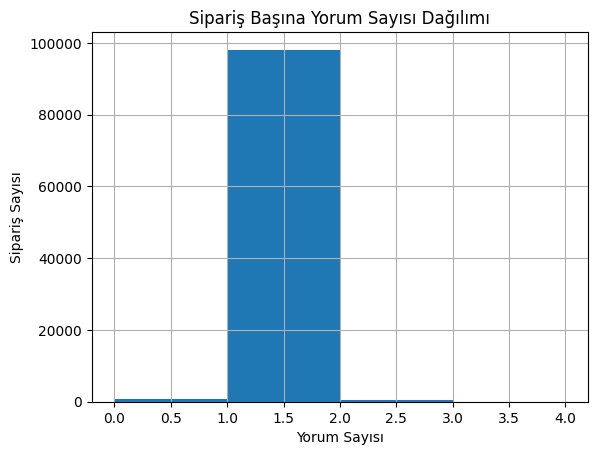

In [14]:
import matplotlib.pyplot as plt

reviews_per_order = orders_reviews.groupby('order_id')['review_id'].count()

reviews_per_order.hist(bins=range(0, 5))
plt.title("Sipariş Başına Yorum Sayısı Dağılımı")
plt.xlabel("Yorum Sayısı")
plt.ylabel("Sipariş Sayısı")
plt.show()

## 📝 Özet

Bu notebook'ta Olist veri seti üzerinde temel bir keşifsel analiz (EDA) yapıldı:

1. **Tablo büyüklükleri:** `orders`, `order_reviews`, `sellers`, `products`, `customers`
   tablolarındaki benzersiz ID sayıları `nunique()` ile hesaplandı.
   (orders: 99441, order_reviews: 98410, sellers: 3095, products: 32951, customers: 99441)

2. **Sipariş–yorum ilişkisi:** `orders` ve `order_reviews` tabloları `order_id` üzerinden
   **left merge** ile birleştirildi. Bu birleştirme sırasında satır sayısının 99441'den
   99992'ye çıktığı gözlemlendi — bazı siparişlerin **birden fazla review**'a sahip
   olduğu (`value_counts()` ile doğrulandı) ortaya çıktı.

3. **Eksik yorumlar:** Toplam sipariş sayısı ile en az bir review'u olan benzersiz
   sipariş sayısı arasındaki fark alınarak, **768 siparişin hiç review'u olmadığı**
   hesaplandı ve test ile doğrulandı.

4. **Görselleştirme:** Sipariş başına yorum sayısı dağılımı histogramla çizildi.
   İlk denemede `.size()` kullanıldığında "0 review" barının görünmediği fark edildi —
   çünkü `left merge` sonrası review'u olmayan siparişler bile birer satır olarak
   kalıyor, `.size()` bunu 1 sayıyor. Sorun `.count()`'a geçilerek çözüldü, çünkü
   `.count()` yalnızca `NaN` olmayan değerleri sayıyor.

**Öğrenilen temel kavram:** `merge` sonrası satır çoğalması ve `.size()` / `.count()`
farkının, eksik veri (`NaN`) içeren analizlerde sonucu nasıl etkileyebileceği.